In [1]:
# Import Libraries & Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error


#Insurance Charges Prediction
# Load dataset
df = pd.read_csv('insurance.csv')

print(df.shape)        # (1338, 7)
print(df.head())
print(df.info())
print(df.describe())   # Stats summary

(1338, 7)
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
               age          bmi     children       charges
count  1338.000000  13

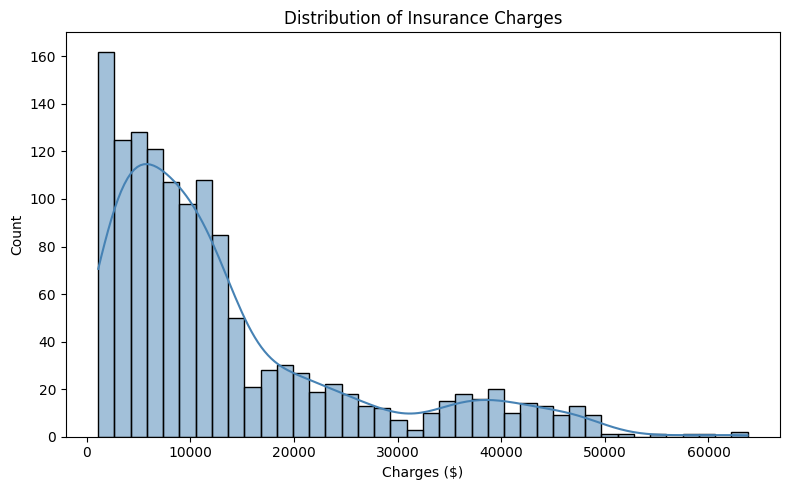

In [3]:
#Explore & Visualize the Data

#Check distribution of charges
plt.figure(figsize=(8, 5))
sns.histplot(df['charges'], bins=40, kde=True, color='steelblue')
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges ($)')
plt.tight_layout()
plt.show()

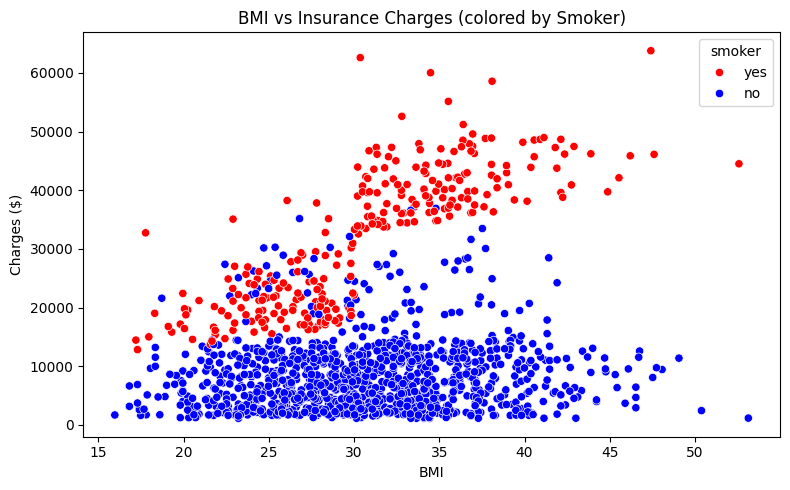

In [4]:
#How BMI impacts charges?
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='bmi', y='charges',
                hue='smoker', palette={'yes':'red', 'no':'blue'})
plt.title('BMI vs Insurance Charges (colored by Smoker)')
plt.xlabel('BMI')
plt.ylabel('Charges ($)')
plt.tight_layout()
plt.show()

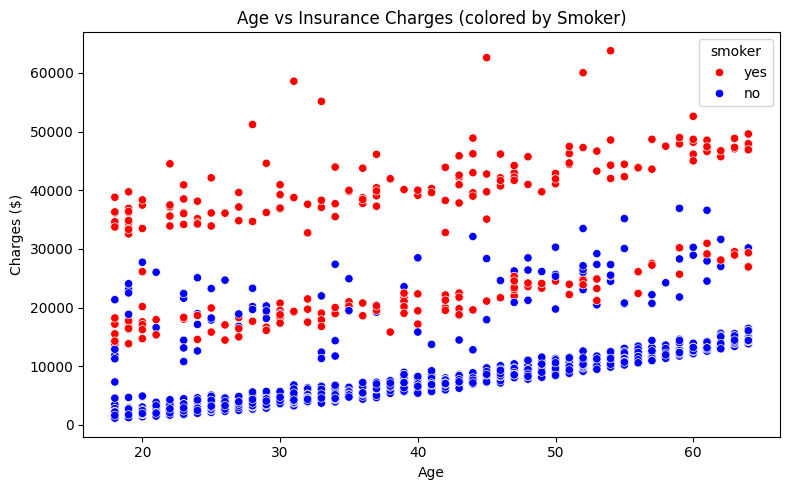

In [5]:
#How Age impacts charges?
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='age', y='charges',
                hue='smoker', palette={'yes':'red', 'no':'blue'})
plt.title('Age vs Insurance Charges (colored by Smoker)')
plt.xlabel('Age')
plt.ylabel('Charges ($)')
plt.tight_layout()
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_28208\2197857627.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='smoker', y='charges',


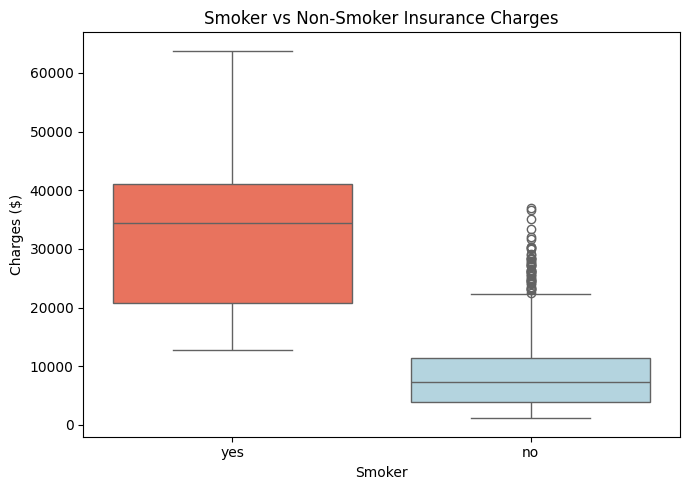

In [6]:
#Smoking status impact (Box plot)
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='smoker', y='charges',
            palette={'yes':'tomato', 'no':'lightblue'})
plt.title('Smoker vs Non-Smoker Insurance Charges')
plt.xlabel('Smoker')
plt.ylabel('Charges ($)')
plt.tight_layout()
plt.show()

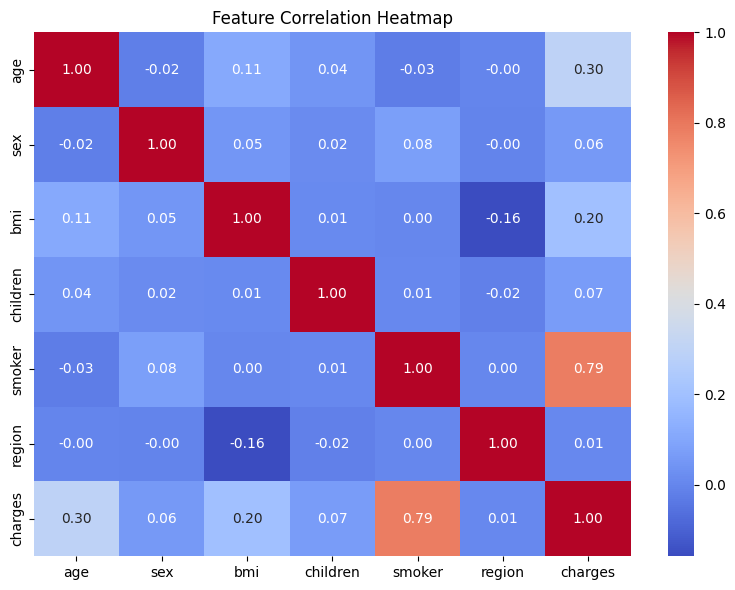

In [8]:
#Correlation Heatmap
# Encode ALL text columns before correlation
df_corr = df.copy()
df_corr['smoker'] = df_corr['smoker'].map({'yes': 1, 'no': 0})
df_corr['sex']    = df_corr['sex'].map({'male': 1, 'female': 0})
df_corr['region'] = df_corr['region'].map({
    'southwest': 0,
    'southeast': 1,
    'northwest': 2,
    'northeast': 3
})

# Now heatmap will work
plt.figure(figsize=(8, 6))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [9]:
#Encode Categorical Columns
le = LabelEncoder()

df['sex']    = le.fit_transform(df['sex'])       # male=1, female=0
df['smoker'] = le.fit_transform(df['smoker'])    # yes=1, no=0
df['region'] = le.fit_transform(df['region'])    # 0,1,2,3

print(df.head())

   age  sex     bmi  children  smoker  region      charges
0   19    0  27.900         0       1       3  16884.92400
1   18    1  33.770         1       0       2   1725.55230
2   28    1  33.000         3       0       2   4449.46200
3   33    1  22.705         0       0       1  21984.47061
4   32    1  28.880         0       0       1   3866.85520


In [10]:
#Split Features & Target
X = df.drop('charges', axis=1)   # Features
y = df['charges']                 # Target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test: ", X_test.shape)



Train: (1070, 6)
Test:  (268, 6)


In [11]:
#Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

In [12]:
#Evaluate — MAE & RMSE
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = model.score(X_test, y_test)

print(f"MAE  : ${mae:,.2f}")
print(f"RMSE : ${rmse:,.2f}")
print(f"R²   : {r2:.4f}")

MAE  : $4,186.51
RMSE : $5,799.59
R²   : 0.7833


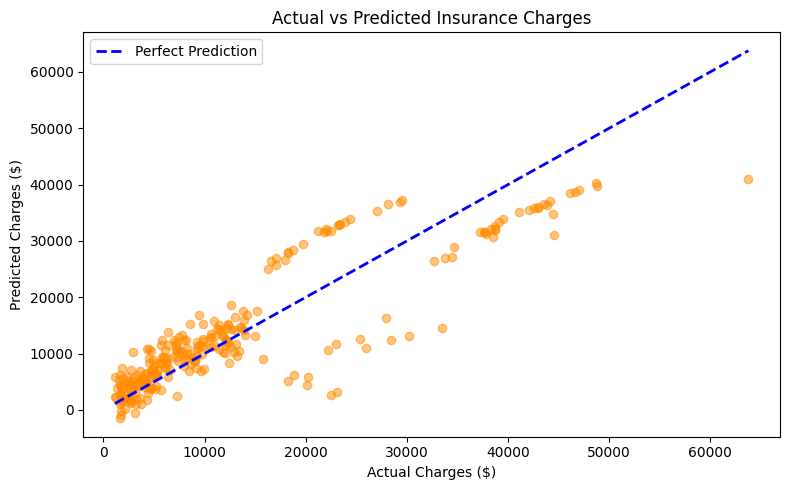

In [13]:
#Visualize Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='darkorange')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'b--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Charges ($)')
plt.ylabel('Predicted Charges ($)')
plt.title('Actual vs Predicted Insurance Charges')
plt.legend()
plt.tight_layout()
plt.show()

    Feature   Coefficient
4    smoker  23647.818096
3  children    425.091456
2       bmi    335.781491
0       age    257.056264
1       sex    -18.791457
5    region   -271.284266


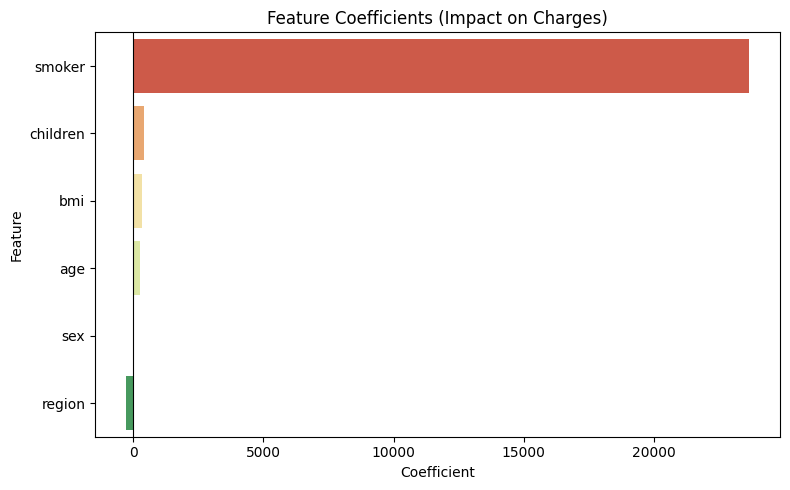

In [15]:
#Check Feature Coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print(coef_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=coef_df, x='Coefficient', y='Feature', 
            hue='Feature', palette='RdYlGn', legend=False)
plt.title('Feature Coefficients (Impact on Charges)')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()